## MovieLens 1M Dataset – EDA for Matrix Factorization Recommender
#
# Goals:
# - Understand rating distribution, user activity, item popularity
# - Check sparsity and its impact on factorization
# - Identify possible improvements: filtering thresholds, normalization, side information

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from utils.data_loader import MovieLensLoader
from utils.matrix_creation import create_user_item_matrix, filter_sparse_data

In [3]:
# Load raw data
loader = MovieLensLoader()
ratings = loader.load_ratings()
movies = loader.load_movies()
users = loader.load_users()

INFO:utils.data_loader:📁 Loader initialized | Data: data/ | Processed: processed/
INFO:utils.data_loader:📂 Loading: data/ratings.dat
INFO:utils.data_loader:✅ Loaded 1000209 rows from ratings.dat
INFO:utils.data_loader:📂 Loading: data/movies.dat
INFO:utils.data_loader:✅ Loaded 3883 rows from movies.dat
INFO:utils.data_loader:📂 Loading: data/users.dat
INFO:utils.data_loader:✅ Loaded 6040 rows from users.dat


In [4]:
print("Ratings shape:", ratings.shape)
print("Movies shape:", movies.shape)
print("Users shape:", users.shape)

Ratings shape: (1000209, 4)
Movies shape: (3883, 3)
Users shape: (6040, 5)


## 1. Rating Distribution

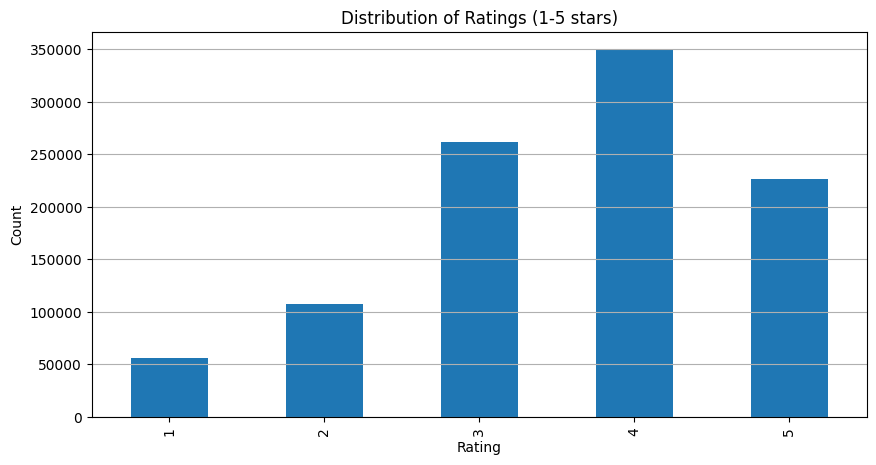

In [5]:
plt.figure(figsize=(10,5))
ratings['rating'].value_counts().sort_index().plot(kind='bar')
plt.title('Distribution of Ratings (1-5 stars)')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.grid(axis='y')
plt.show()

In [6]:
print("Unique ratings:", ratings['rating'].unique())

Unique ratings: [5 3 4 2 1]


## 2. User Activity

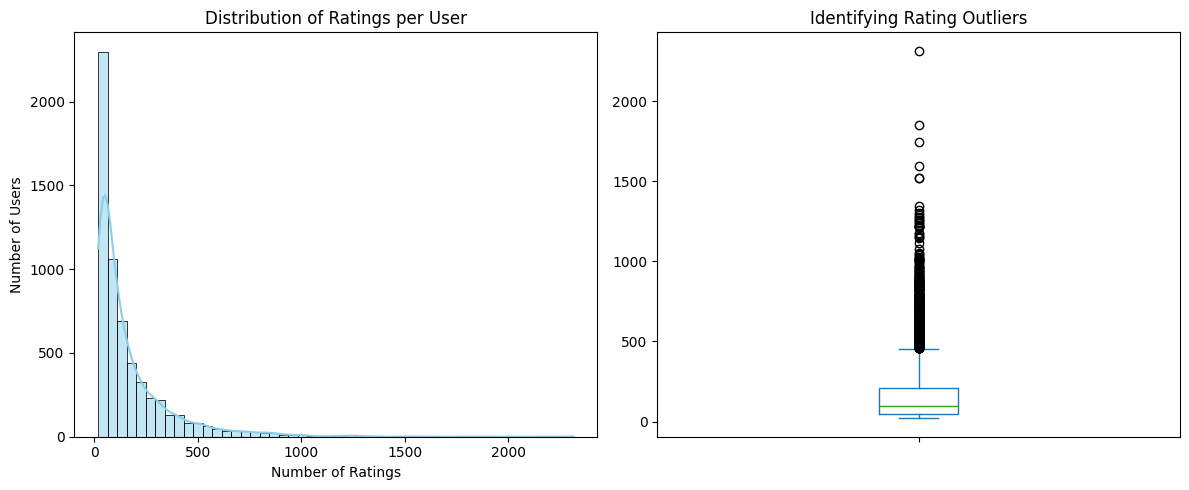

Min ratings per user: 20
Max: 2314, Median: 96.0


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

user_rating_counts = ratings.groupby('user_id').size()

plt.figure(figsize=(12, 5))

# Histogram
plt.subplot(1, 2, 1)
sns.histplot(user_rating_counts, bins=50, kde=True, color='skyblue')
plt.title('Distribution of Ratings per User')
plt.xlabel('Number of Ratings')
plt.ylabel('Number of Users')

# Boxplot (The Fixed Line)
plt.subplot(1, 2, 2)
user_rating_counts.plot.box() # or sns.boxplot(y=user_rating_counts)
plt.title('Identifying Rating Outliers')

plt.tight_layout()
plt.show()

print(f"Min ratings per user: {user_rating_counts.min()}")
print(f"Max: {user_rating_counts.max()}, Median: {user_rating_counts.median()}")

## 3. Item Popularity

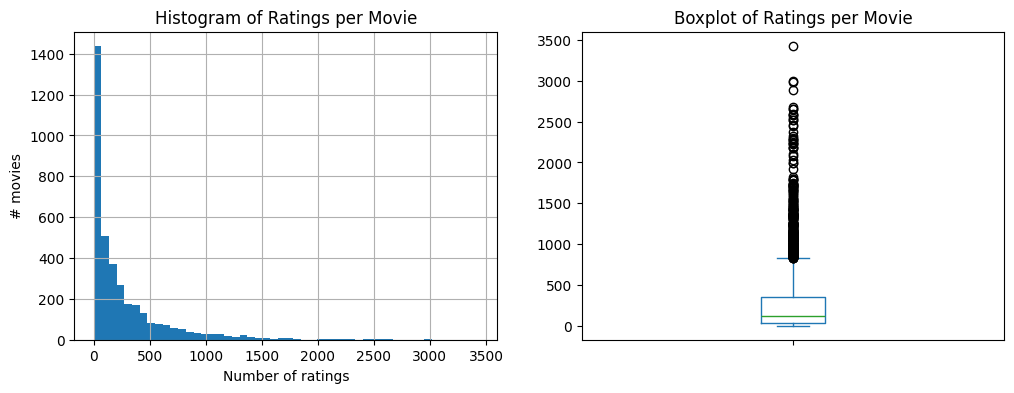

Min ratings per movie: 1
Max: 3428, Median: 123.5
Movies with <50 ratings: 1192


In [8]:
item_rating_counts = ratings.groupby('movie_id').size()
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
item_rating_counts.hist(bins=50)
plt.title('Histogram of Ratings per Movie')
plt.xlabel('Number of ratings')
plt.ylabel('# movies')
plt.subplot(1,2,2)
item_rating_counts.plot.box()
plt.title('Boxplot of Ratings per Movie')
plt.show()

print(f"Min ratings per movie: {item_rating_counts.min()}")
print(f"Max: {item_rating_counts.max()}, Median: {item_rating_counts.median()}")
print(f"Movies with <50 ratings: {(item_rating_counts < 50).sum()}")

## 4. Sparsity of User-Item Matrix

In [9]:
clean_ratings = filter_sparse_data(ratings, min_ratings_per_user=5, min_ratings_per_movie=10)
print(f"After filtering: {len(clean_ratings)} interactions")

# Create matrix
matrix = create_user_item_matrix(clean_ratings)
n_users, n_items = matrix.shape
n_ratings = (matrix.values > 0).sum()
sparsity = 1 - n_ratings / (n_users * n_items)
print(f"Matrix shape: {n_users} users × {n_items} items")
print(f"Observed ratings: {n_ratings}")
print(f"Sparsity: {sparsity*100:.2f}%")

INFO:utils.matrix_creation:🧹 Filtering sparse data (Min: User=5, Movie=10)
INFO:utils.matrix_creation:✅ Remaining interactions: 998539
INFO:utils.matrix_creation:🎬 Creating User-Item matrix...


After filtering: 998539 interactions


INFO:utils.matrix_creation:✅ Matrix Shape: (6040, 3260)


Matrix shape: 6040 users × 3260 items
Observed ratings: 998539
Sparsity: 94.93%


## 5. User and Item Bias Analysis

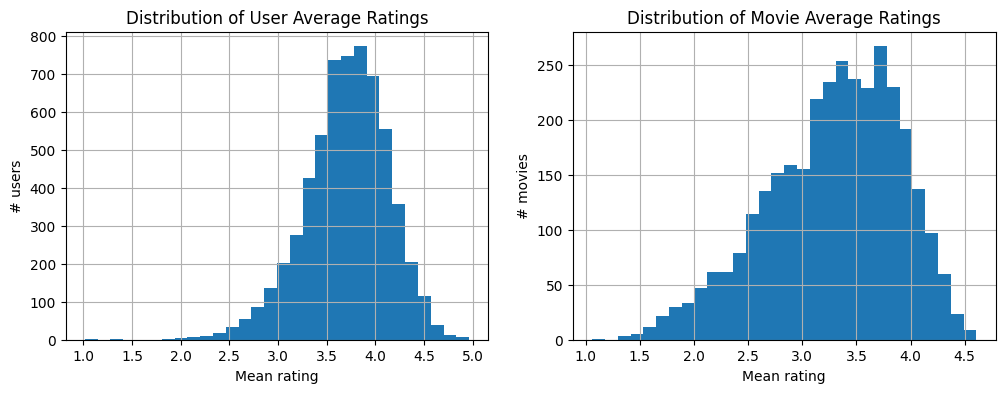

User mean std: 0.429
Item mean std: 0.612


In [10]:
user_means = matrix.mean(axis=1)
item_means = matrix.mean(axis=0)

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
user_means.hist(bins=30)
plt.title('Distribution of User Average Ratings')
plt.xlabel('Mean rating')
plt.ylabel('# users')
plt.subplot(1,2,2)
item_means.hist(bins=30)
plt.title('Distribution of Movie Average Ratings')
plt.xlabel('Mean rating')
plt.ylabel('# movies')
plt.show()

# Check variance
print(f"User mean std: {user_means.std():.3f}")
print(f"Item mean std: {item_means.std():.3f}")

## 6. Rating Distribution by User Activity (Example)

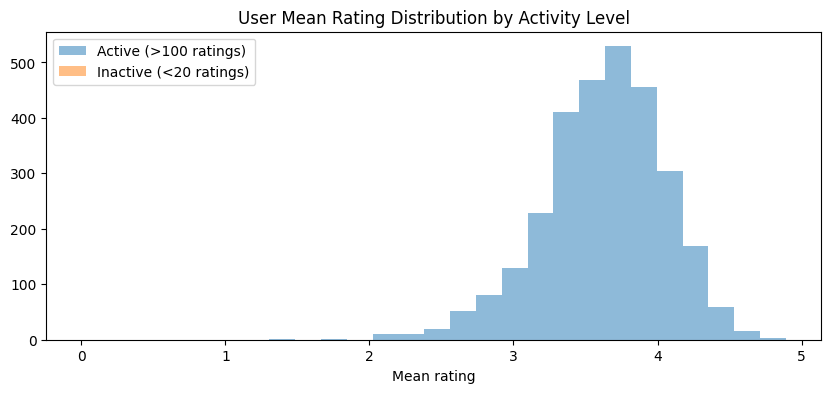

In [11]:
# Show that users with few ratings have higher variance (potential noise)
active_users = user_rating_counts[user_rating_counts >= 100].index
inactive_users = user_rating_counts[user_rating_counts < 20].index

active_means = ratings[ratings['user_id'].isin(active_users)].groupby('user_id')['rating'].mean()
inactive_means = ratings[ratings['user_id'].isin(inactive_users)].groupby('user_id')['rating'].mean()

plt.figure(figsize=(10,4))
plt.hist(active_means, bins=20, alpha=0.5, label='Active (>100 ratings)')
plt.hist(inactive_means, bins=20, alpha=0.5, label='Inactive (<20 ratings)')
plt.legend()
plt.title('User Mean Rating Distribution by Activity Level')
plt.xlabel('Mean rating')
plt.show()

## 7. Temporal Effects? (Optional – using timestamp)

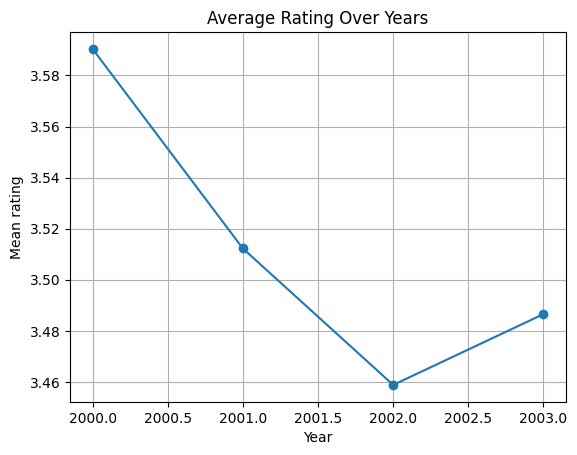

In [12]:
# Convert timestamp to datetime
ratings['date'] = pd.to_datetime(ratings['timestamp'], unit='s')
ratings['year'] = ratings['date'].dt.year
ratings['month'] = ratings['date'].dt.month

# Check if ratings drift over time
avg_rating_by_year = ratings.groupby('year')['rating'].mean()
plt.plot(avg_rating_by_year.index, avg_rating_by_year.values, marker='o')
plt.title('Average Rating Over Years')
plt.xlabel('Year')
plt.ylabel('Mean rating')
plt.grid(True)
plt.show()

## 8. Genre Information (Potential Side Feature)

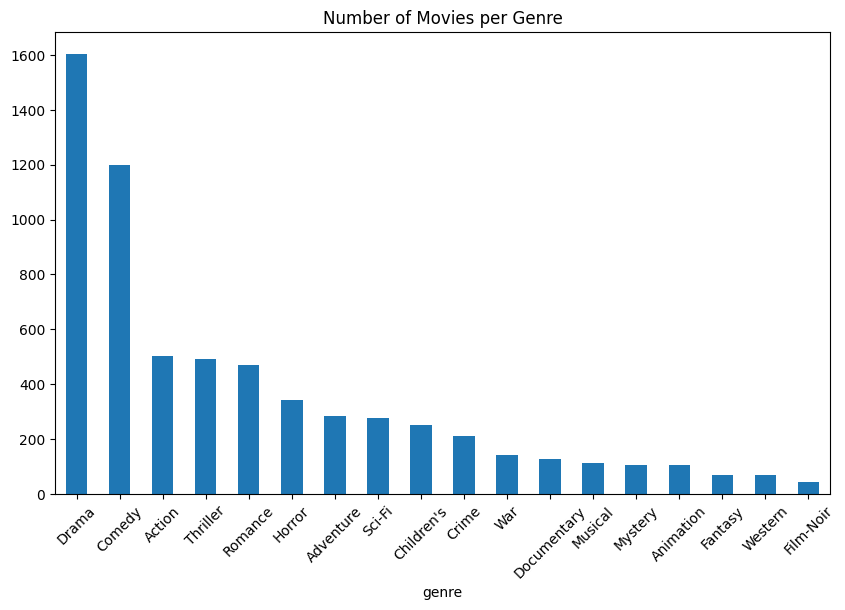

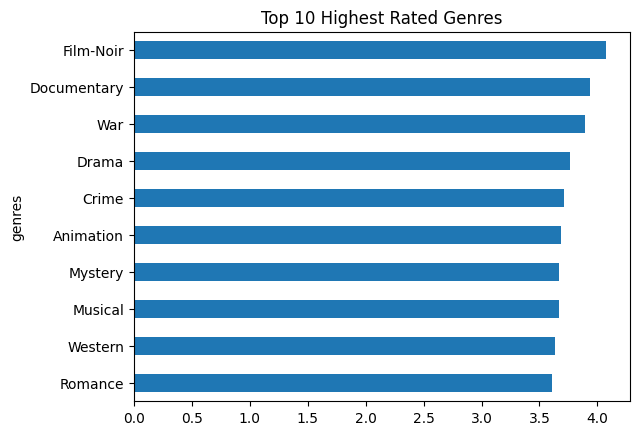

In [13]:
# Parse genres
genres = movies['genres'].str.split('|', expand=True).stack().reset_index(level=1, drop=True)
genres.name = 'genre'
movies_with_genre = movies.join(genres)

# Count genre occurrences
genre_counts = movies_with_genre['genre'].value_counts()
plt.figure(figsize=(10,6))
genre_counts.plot(kind='bar')
plt.title('Number of Movies per Genre')
plt.xticks(rotation=45)
plt.show()

# Check if certain genres have higher ratings (merge with ratings)
movie_genres = movies.set_index('movie_id')['genres'].str.split('|').explode().reset_index()
merged = ratings.merge(movie_genres, on='movie_id')
genre_ratings = merged.groupby('genres')['rating'].mean().sort_values()
genre_ratings.tail(10).plot(kind='barh')
plt.title('Top 10 Highest Rated Genres')
plt.show()

## 9. Summary and Recommendations for Improvement
Based on EDA, we observe:
- Ratings are mostly 4 and 5 stars (positive bias).
- Many users have few ratings (<20), but we already filtered at 5.
- Movies with few ratings (<10) are filtered out – maybe we can keep more.
- Sparsity is very high (~98%), typical for collaborative filtering.
- User and item means vary, so mean-centering is appropriate.
- No strong temporal drift.
**Potential improvements to try:**
1. **Adjust filtering thresholds** – keep more movies (e.g., min_ratings_per_movie=5) to increase coverage.
2. **Use item‑wise normalization** instead of user‑wise, or both (double centering).
3. **Add user and item biases** to the PMF model (like SVD with biases). This often improves accuracy.
4. **Use weighted loss** – penalize errors on popular movies or active users differently.
5. **Incorporate genre features** as side information (hybrid model) – but that's beyond the project's scope.
We'll start with bias addition and better filtering.